# Análise dos fatores que influenciam a satisfação dos nossos clientes.

O objetivo deste projeto é analisar os determinantes da variabilidade do NPS no cenário de expansão do e-commerce, identificando os fatores operacionais e comportamentais que diferenciam promotores de detratores para otimizar a jornada do cliente.

**Principais perguntas a serem respondidas:**
Quais fatores influenciam na satisfação do nossos clientes?
Como podemos agir de forma proativa para melhorar a experiência dos nossos clientes?
</br>


##Etapa 1: Pré processamento dos dados.



In [1]:
#Importa as bibliotecas necessárias para a analise.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Definição do link RAW do GitHub
# O link raw permite que o pandas leia o conteúdo puro do CSV, não necessitando importar o arquivo para o Google Colab
url_raw = 'https://raw.githubusercontent.com/andersonsariliods/FIAP1AST_TechChallenge/refs/heads/main/Fase_1/Dados/desafio_nps_fase_1.csv'

In [3]:
# Carregamento dos dados para um dataframe
df = pd.read_csv(url_raw)

In [4]:
#Verifica se o dataframe foi carregado corretamente.
df.head(5)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [5]:
# Verifica os tipo de dados das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [11]:
# Verifica se há discrepâncias nos dados
df[['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days',
    'freight_value', 'delivery_attempts','customer_service_contacts', 'resolution_time_days',
    'nps_score', 'repeat_purchase_30d', 'complaints_count','csat_internal_score']].describe()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,43.396000,61.322400,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,14.888487,34.478729,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,18.000000,1.000000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,31.000000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,43.000000,62.000000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,56.000000,91.000000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,69.000000,119.000000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [12]:
# Cria uma função para categorizar o NPS
def categorizar_nps(score):
    if score >= 9: return 'Promotor'
    elif score >= 7: return 'Neutro'
    else: return 'Detrator'

In [13]:
# Cria uma nova coluna chamada nps_category
# Classifica os dados do campo nps_score chamando a função categorizar_nps
df['nps_category'] = df['nps_score'].apply(categorizar_nps)

In [14]:
# Realiza o calculo do NPS
total = len(df) #Qtde. clientes totais
counts = df['nps_category'].value_counts() #Qtde. clientes por categoria
pct_promotores = (counts.get('Promotor', 0) / total) * 100 #Percentual de cliente promotores
pct_detratores = (counts.get('Detrator', 0) / total) * 100 #Percentual de clientes detratores
nps_total = pct_promotores - pct_detratores #Calculo final do NPS.

In [15]:
# Exibe o valor do NPS total
# O valor obtido indica um estado critico de satisfação do nossos clientes
print(nps_total)

-79.96


## Etapa 2 - Analise dos exploratória dos dados

In [16]:
#Define todos os grids para fundo branco.
sns.set_style("whitegrid")

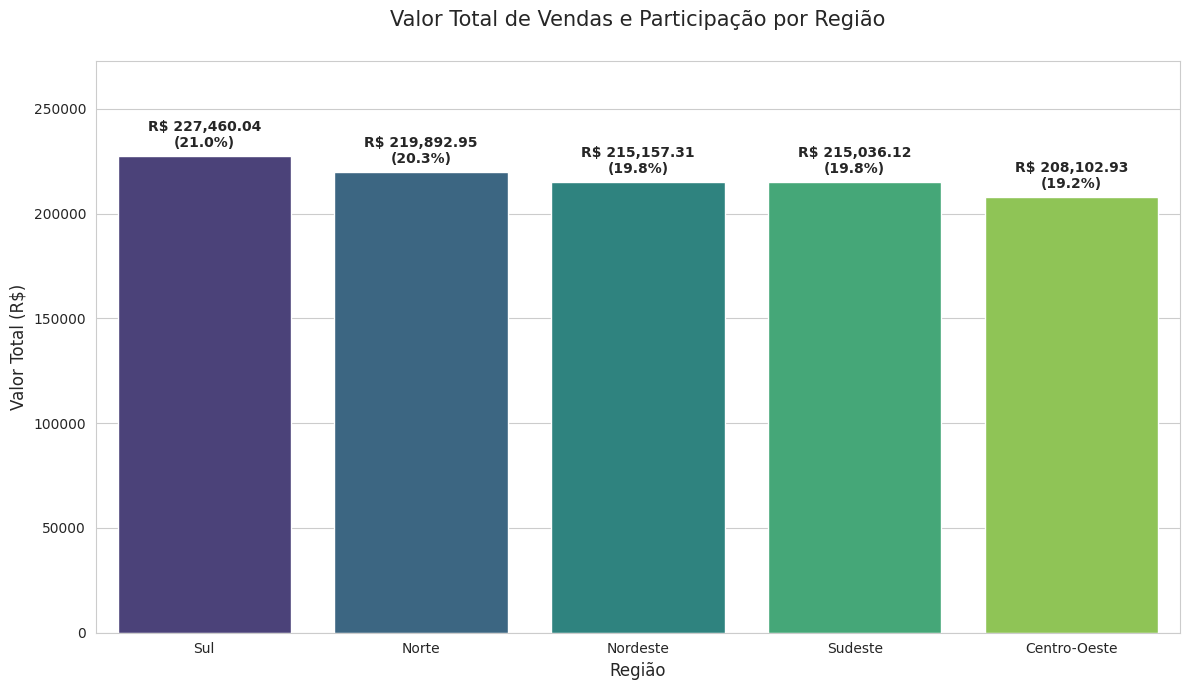

In [17]:
# Grafico de vendas por região

# Agrupando o valor total de pedidos por região
vendas_regiao = df.groupby('customer_region')['order_value'].sum().sort_values(ascending=False)
vendas_total = vendas_regiao.sum()

# Configura o tamanho do grafico
plt.figure(figsize=(12, 7))


# Removendo o argumento legend para evitar erro de versão
ax = sns.barplot(
    x=vendas_regiao.index,
    y=vendas_regiao.values,
    hue=vendas_regiao.index,
    palette="viridis"
)

# Removendo a legenda automática se existir
if ax.get_legend():
    ax.get_legend().remove()

# Adicionando rótulos de valor total e percentual de participação
for p in ax.patches:
    valor = p.get_height()
    if valor > 0:
        percentual = (valor / vendas_total) * 100
        ax.annotate(f'R$ {valor:,.2f}\n({percentual:.1f}%)',
                    (p.get_x() + p.get_width() / 2., valor),
                    ha='center', va='center',
                    xytext=(0, 15),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.title('Valor Total de Vendas e Participação por Região', fontsize=15, pad=25)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)

# Ajuste do limite do eixo Y para os rótulos
plt.ylim(0, vendas_regiao.max() * 1.2)

plt.tight_layout()
plt.savefig('vendas_por_regiao_percentual.png')
plt.show()

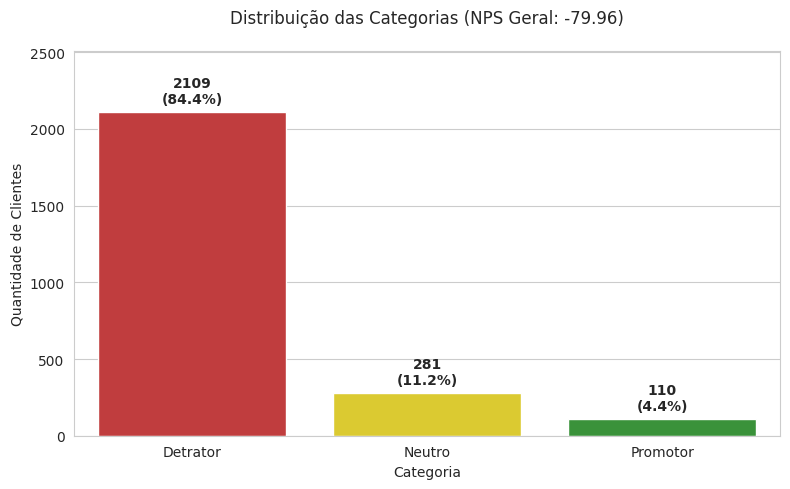

In [18]:
# Gráfico 1: Distribuição dos clientes de acordo com a classificação do NPS
# Configuração do Gráfico de Distribuição com Percentuais
plt.figure(figsize=(8, 5))
cores = {'Detrator': '#d62728', 'Neutro': '#f7e115', 'Promotor': '#2ca02c'}

# Criando o gráfico
ax = sns.countplot(
    data=df,
    x='nps_category',
    hue='nps_category',
    order=['Detrator', 'Neutro', 'Promotor'],
    palette=cores
)

# Remove a legenda
if ax.get_legend():
    ax.get_legend().remove()

# Adicionando os valores absolutos e percentuais acima das barras
total_clientes = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total_clientes) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 15), # Deslocamento vertical do texto
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.title(f'Distribuição das Categorias (NPS Geral: {nps_total:.2f})', pad=20)
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Categoria')

# Ajusta o limite do eixo Y para garantir que os textos não sejam cortados
plt.ylim(0, df['nps_category'].value_counts().max() + 400)

plt.tight_layout()
plt.show()

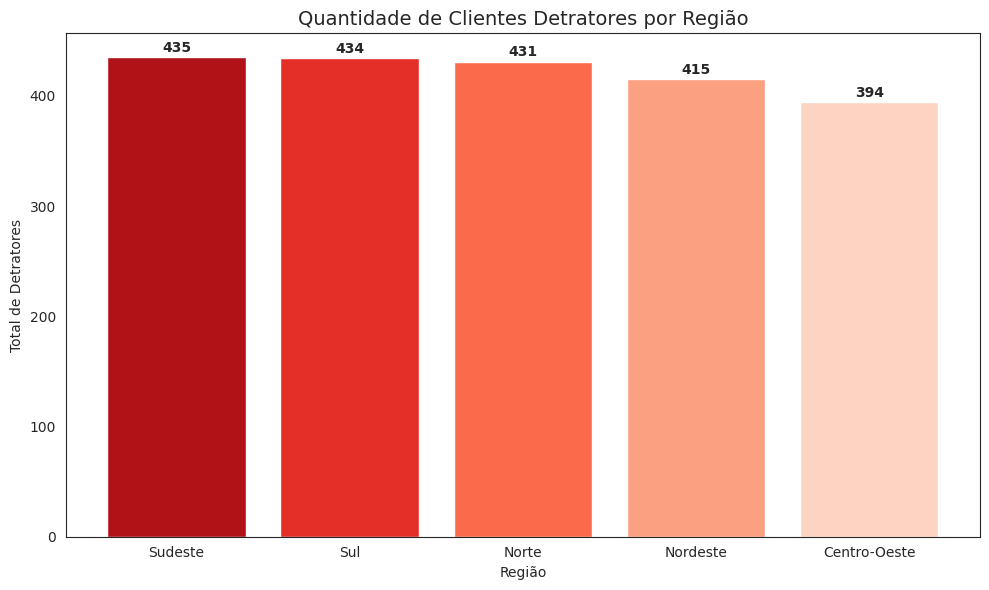

In [19]:
# Grafico 2: Clientes detratores por regiao
#Filtrando detratores
detratores_df = df[df['nps_category'] == 'Detrator']
regiao_impacto = detratores_df['customer_region'].value_counts().sort_values(ascending=False)

# Visualização Simples
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Usando barplot simples sem hue para evitar problemas de anotação
colors = sns.color_palette("Reds_r", len(regiao_impacto))
plt.bar(regiao_impacto.index, regiao_impacto.values, color=colors)

plt.title('Quantidade de Clientes Detratores por Região', fontsize=14)
plt.ylabel('Total de Detratores')
plt.xlabel('Região')

# Adicionando os valores no topo das barras
for i, v in enumerate(regiao_impacto.values):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('impacto_regional.png')
plt.show()

In [20]:
# Calculo do NPS por Região
nps_resumo = []
for reg in df['customer_region'].unique():
    base = df[df['customer_region'] == reg]
    n_prom = len(base[base['nps_category'] == 'Promotor'])
    n_det = len(base[base['nps_category'] == 'Detrator'])
    n_total = len(base)
    nps = ((n_prom - n_det) / n_total) * 100
    nps_resumo.append({'Região': reg, 'NPS': nps, 'Total': n_total})

df_final = pd.DataFrame(nps_resumo).sort_values('NPS')
print(df_final)

         Região        NPS  Total
3         Norte -81.620553    506
0      Nordeste -81.237113    485
4       Sudeste -79.230769    520
1           Sul -78.886756    521
2  Centro-Oeste -78.846154    468


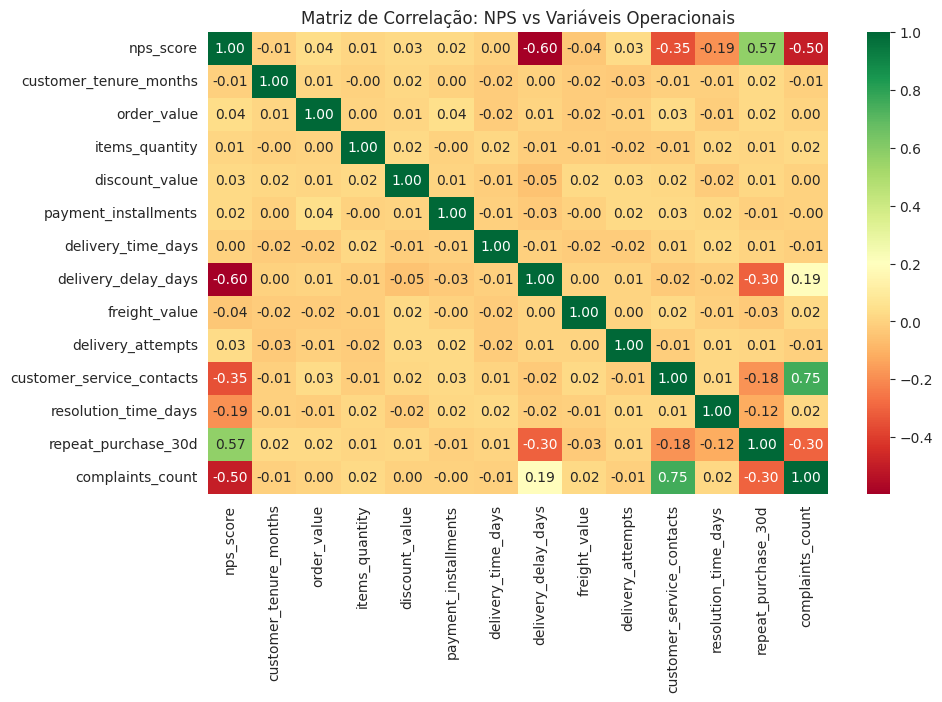

In [21]:
# Gráfico 3: Heatmap de Correlação
# Analisar se há uma correlação entre o NPS e as demais variaveis.
plt.figure(figsize=(10, 6))
cols_corr = ['nps_score', 'customer_tenure_months','order_value','items_quantity','discount_value','payment_installments',
             'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts',
             'resolution_time_days', 'repeat_purchase_30d', 'complaints_count']
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriz de Correlação: NPS vs Variáveis Operacionais')
plt.show()